In [3]:
from src.train.video_dataset import UniDataset
x = UniDataset('data/sequences/', ['r1','flow'],
                 512,
                 0.1,
                 [],
                 0.1,
                 0.1,
                 [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re

def natural_sort_key(filename):
    """Extracts numbers from filenames for proper sorting."""
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', filename)]

def load_images_from_directory(directory, num_images=10, sort=False):
    """Load image file paths from a directory, with optional sorting."""
    image_files = sorted([f for f in os.listdir(directory) if f.endswith(('.png', '.jpg'))])
    
    if sort:
        image_files = sorted(image_files, key=natural_sort_key)  # Apply sorting only if needed

    return [os.path.join(directory, f) for f in image_files[6:num_images+6]]

def read_and_resize_images(image_paths, target_size=(1920, 1080)):
    """Read images and resize to 1080p resolution."""
    images = [cv2.resize(cv2.imread(img_path), target_size) for img_path in image_paths]
    return images

def extract_vertical_patch(image, patch_width=300):
    """Extract a central vertical patch from an image."""
    h, w, _ = image.shape
    center_x = w // 2  # Find the center width
    left_x = max(0, center_x - patch_width // 2)
    right_x = min(w, center_x + patch_width // 2)
    return image[:, left_x:right_x]  # Extract vertical patch

# Directories
original_dir = "/data/maryam.sana/vimeo_unicontrol/Uni-ControlNet/data/UVG/images/original/Beauty"
pred_dir = "/data/maryam.sana/Uni-ControlNet/test_codec/revised_beauty"

# Load image file paths
original_image_paths = load_images_from_directory(original_dir, num_images=10, sort=False)  # No sorting
pred_image_paths = load_images_from_directory(pred_dir, num_images=10, sort=True)  # Sorting applied

print("Original Images:", [os.path.basename(p) for p in original_image_paths])
print("Predicted Images:", [os.path.basename(p) for p in pred_image_paths])

# Read and resize images
original_images = read_and_resize_images(original_image_paths)
pred_images = read_and_resize_images(pred_image_paths)

# Extract vertical patches
original_patches = [extract_vertical_patch(img) for img in original_images]
pred_patches = [extract_vertical_patch(img) for img in pred_images]

# Visualization with High DPI
fig, axes = plt.subplots(2, 10, figsize=(20,9), dpi=300)  # Higher DPI for better quality

for i in range(10):
    axes[0, i].imshow(cv2.cvtColor(original_patches[i], cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original {i+1}", fontsize=8)

    axes[1, i].imshow(cv2.cvtColor(pred_patches[i], cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Pred {i+1}", fontsize=8)

# Adjust layout to reduce spacing
plt.subplots_adjust(wspace=0.01, hspace=0.1)  # Minimized spacing for better visualization
plt.show()


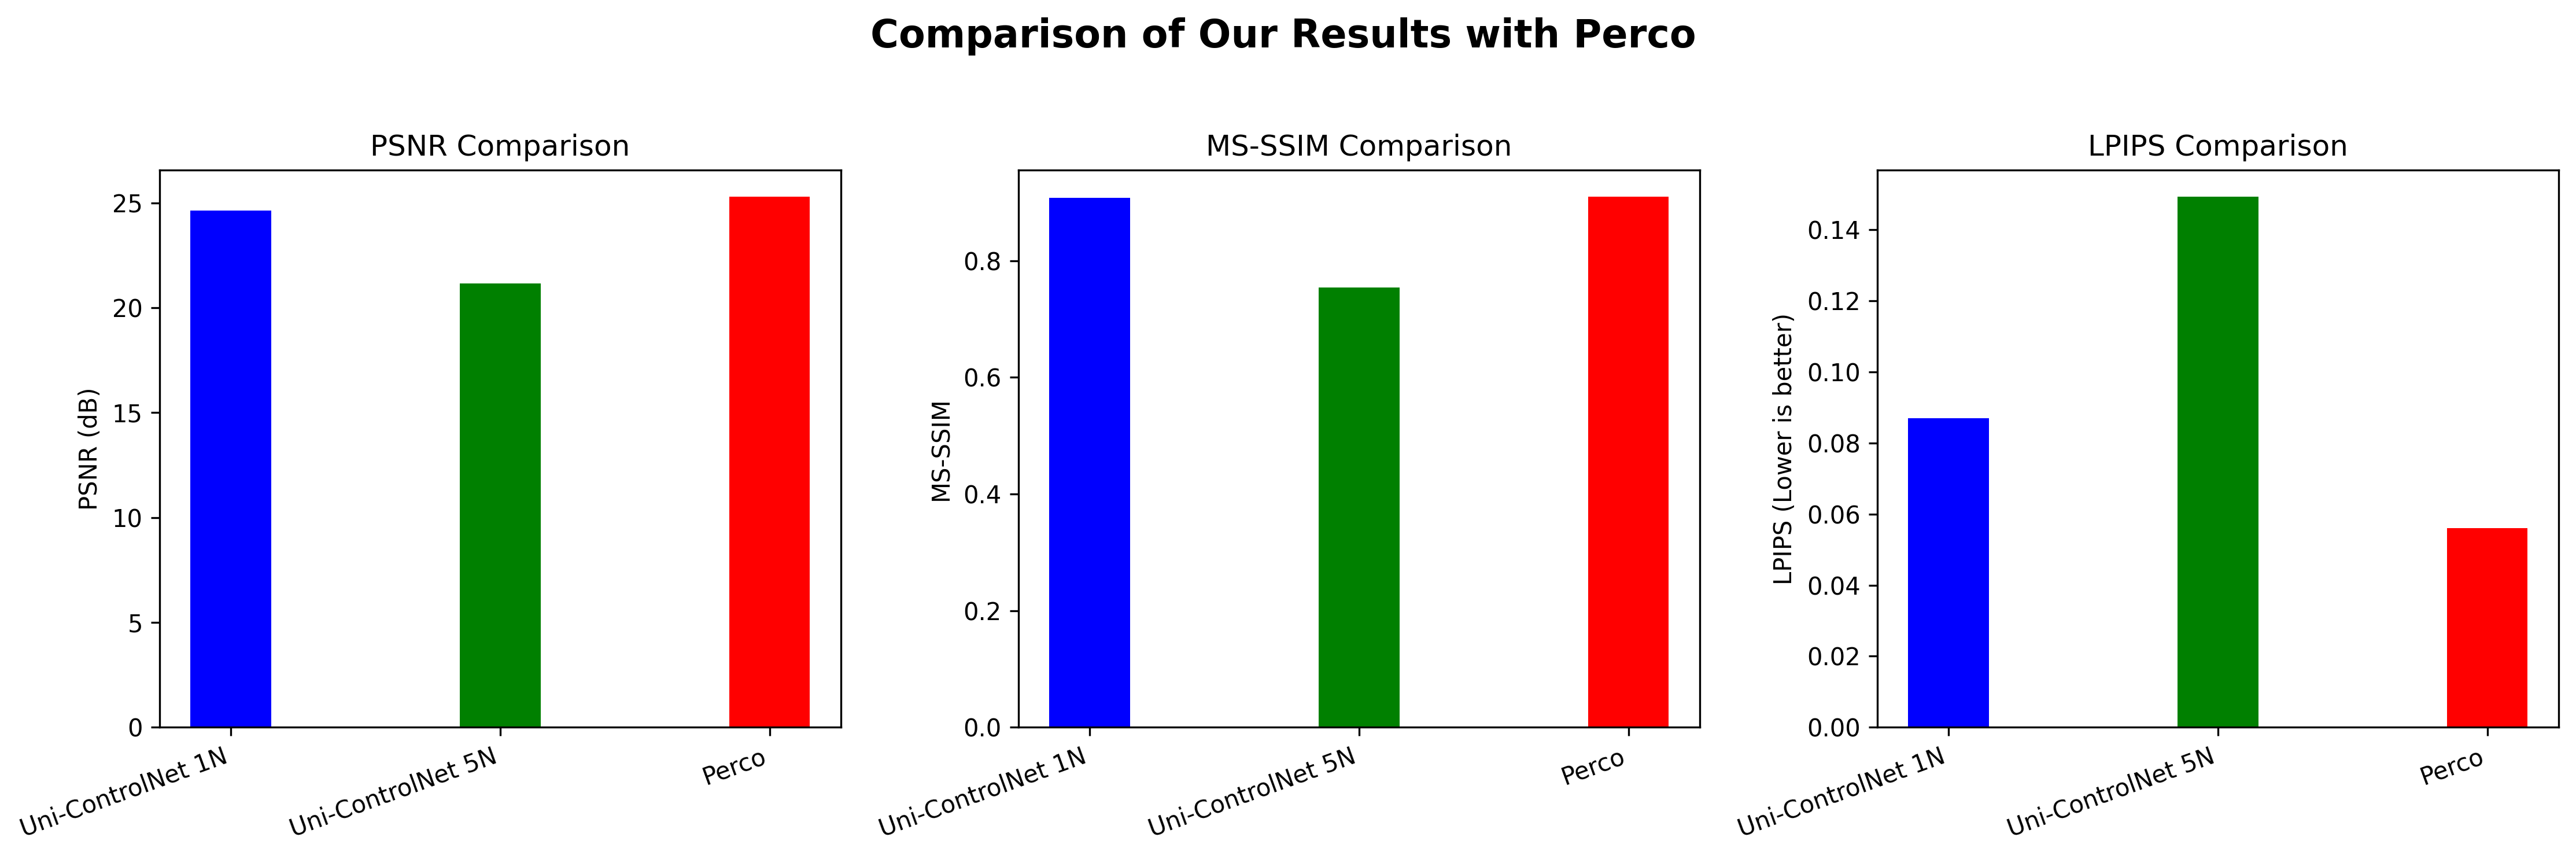

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics data
models = ["Uni-ControlNet 1N", "Uni-ControlNet 5N", "Perco"]

psnr_values = [24.645866834200344, 21.158502101898193, 25.3]
ms_ssim_values = [0.9077658928357638, 0.7538023620843888, 0.91]
lpips_values = [0.08703393317185916, 0.1493741899728775, 0.05597]

# Bar width and positions
bar_width = 0.3
x = np.arange(len(models))

# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(15, 5),dpi=300)
fig.suptitle("Comparison of Our Results with Perco", fontsize=16, fontweight='bold')

# PSNR Bar Chart
axes[0].bar(x, psnr_values, color=['blue', 'green', 'red'], width=bar_width)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha="right")
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR Comparison")

# MS-SSIM Bar Chart
axes[1].bar(x, ms_ssim_values, color=['blue', 'green', 'red'], width=bar_width)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha="right")
axes[1].set_ylabel("MS-SSIM")
axes[1].set_title("MS-SSIM Comparison")

# LPIPS Bar Chart
axes[2].bar(x, lpips_values, color=['blue', 'green', 'red'], width=bar_width)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=20, ha="right")
axes[2].set_ylabel("LPIPS (Lower is better)")
axes[2].set_title("LPIPS Comparison")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the main title
plt.show()


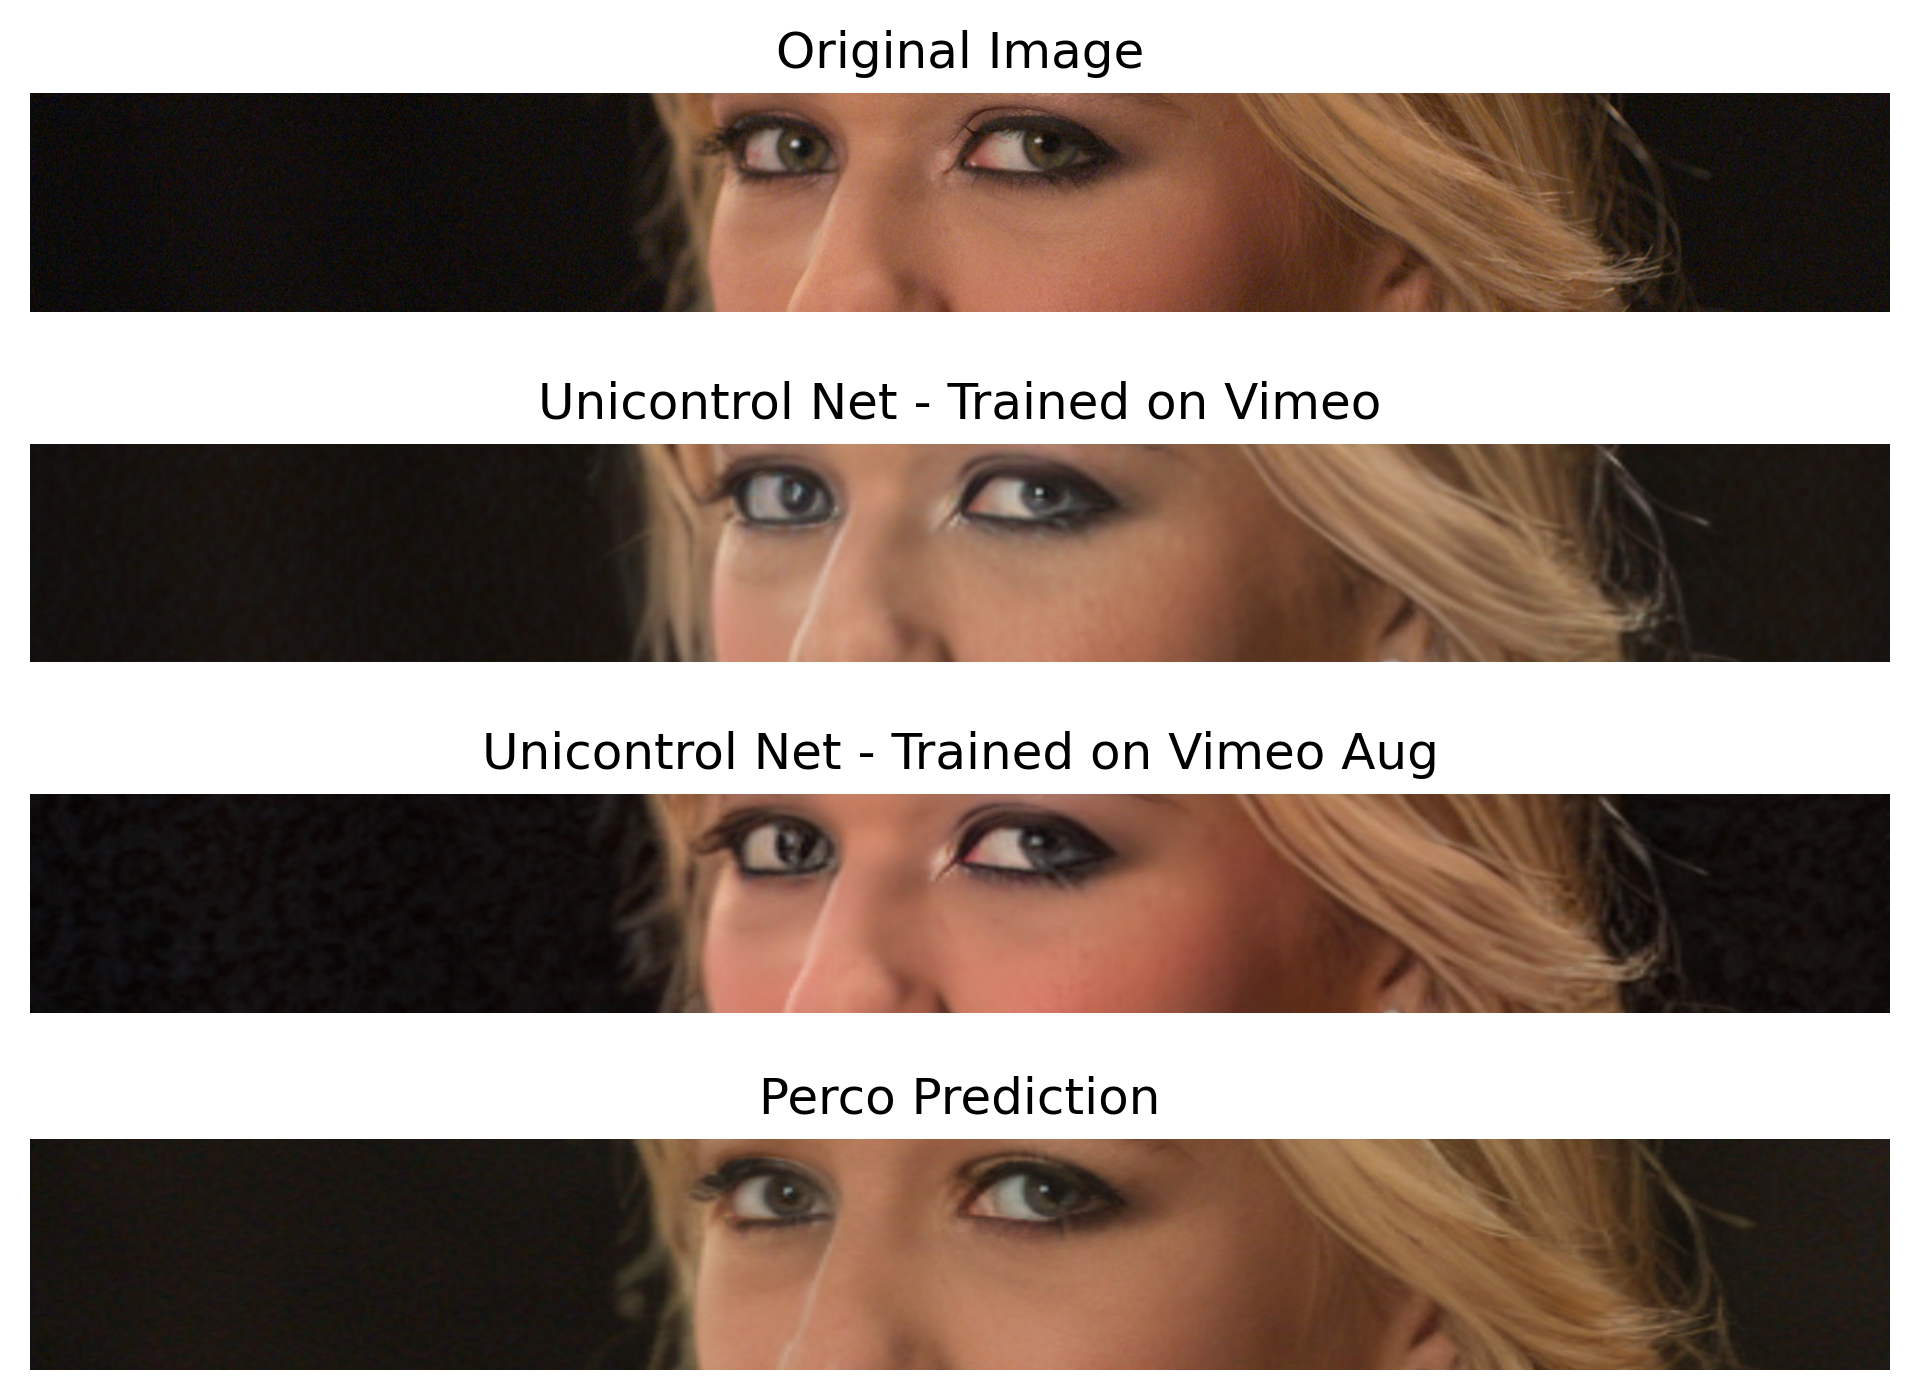

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define paths to images
original_path = "data/UVG/images/original/Beauty/im00002.png"
unicontrol_vimeo_path = "exp_perco_lpips2/preds_op/Beauty/im2_pred.png"
unicontrol_vimeo_aug_path = "exp_perco_lpips_aug2/preds2/Beauty/im2_pred.png"
perco_path = "data/beauty_im00002.png"  # Perco prediction

# Load images
original = cv2.imread(original_path)
unicontrol_vimeo = cv2.imread(unicontrol_vimeo_path)
unicontrol_vimeo_aug = cv2.imread(unicontrol_vimeo_aug_path)
perco = cv2.imread(perco_path)

# Convert from BGR to RGB
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
unicontrol_vimeo = cv2.cvtColor(unicontrol_vimeo, cv2.COLOR_BGR2RGB)
unicontrol_vimeo_aug = cv2.cvtColor(unicontrol_vimeo_aug, cv2.COLOR_BGR2RGB)
perco = cv2.cvtColor(perco, cv2.COLOR_BGR2RGB)

# Resize Perco image to match the original image
perco = cv2.resize(perco, (original.shape[1], original.shape[0]))

# Function to crop an image by removing 'crop_size' pixels from each side
def crop_image(image, crop_size=50):
    h, w, _ = image.shape
    return image[crop_size:h-crop_size, crop_size:w-crop_size]

# Crop Perco image (50 pixels from each side)
perco = crop_image(perco)

# Function to extract a horizontal patch from an image
def extract_horizontal_patch(image, patch_height=220):
    h, w, _ = image.shape
    center_y = h // 2
    top = max(0, center_y - patch_height // 2)
    bottom = min(h, center_y + patch_height // 2)
    return image[top-30:bottom-30, 50:]

# Extract patches
original_patch = extract_horizontal_patch(original)
unicontrol_vimeo_patch = extract_horizontal_patch(unicontrol_vimeo)
unicontrol_vimeo_aug_patch = extract_horizontal_patch(unicontrol_vimeo_aug)
perco_patch = extract_horizontal_patch(perco)

# Plot the patches
fig, axes = plt.subplots(4, 1, figsize=(8, 6), dpi=300)  # Adjusted figure size

# Titles for the rows
titles = ["Original Image", "Unicontrol Net - Trained on Vimeo", "Unicontrol Net - Trained on Vimeo Aug", "Perco Prediction"]
patches = [original_patch, unicontrol_vimeo_patch, unicontrol_vimeo_aug_patch, perco_patch]

# Plot each patch
for ax, patch, title in zip(axes, patches, titles):
    ax.imshow(patch)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

# Reduce spacing between rows
plt.subplots_adjust(hspace=0.05)  # Adjust this value to control row spacing

plt.show()


In [3]:
from PIL import Image
from test_utils import *

# Function to load images as PIL
def load_pil_images(image_paths):
    """Loads images from paths and returns a list of PIL images."""
    return [Image.open(img_path).convert("RGB") for img_path in image_paths]

# Define image paths
original_paths = [
    "data/UVG/images/original/Beauty/im00002.png"
]
unicontrol_vimeo_paths = [
    "exp_perco_lpips2/preds_op/Beauty/im2_pred.png"
]
unicontrol_vimeo_aug_paths = [
    "exp_perco_lpips_aug2/preds2/Beauty/im2_pred.png"
]
perco_paths = [
    "data/perco_pred_im2.png"
]

# Load images
original_images = load_pil_images(original_paths)
unicontrol_vimeo_images = load_pil_images(unicontrol_vimeo_paths)
unicontrol_vimeo_aug_images = load_pil_images(unicontrol_vimeo_aug_paths)
perco_images = load_pil_images(perco_paths)

# Call `calculate_metrics_batch` for each comparison
metrics_vimeo = calculate_metrics_batch(original_images, unicontrol_vimeo_images)
metrics_vimeo_aug = calculate_metrics_batch(original_images, unicontrol_vimeo_aug_images)
metrics_perco = calculate_metrics_batch(original_images, perco_images)

# Print results
print("Metrics for Unicontrol Net - Trained on Vimeo:", metrics_vimeo)
print("Metrics for Unicontrol Net - Trained on Vimeo Aug:", metrics_vimeo_aug)
print("Metrics for Perco Prediction:", metrics_perco)


FileNotFoundError: [Errno 2] No such file or directory: '/data/maryam.sana/Uni-ControlNet/exp_perco_lpips_aug2/preds2/Beauty/im2_pred.png'

In [1]:
import os
from pathlib import Path
from PIL import Image
from test_utils import *
# Replace this with your actual metric function
# from your_module import calculate_metrics_batch

def load_pil_images(image_paths):
    """Loads images from paths and returns a list of PIL images."""
    return [Image.open(img_path).convert("RGB") for img_path in image_paths[:60]]

def sorted_image_paths(directory):
    """Gets sorted image paths (png or jpg) from a directory."""
    return sorted([
        os.path.join(directory, fname)
        for fname in os.listdir(directory)
        if fname.lower().endswith((".png", ".jpg"))
    ])[0:50]

# Define directories
original_dir = "data/UVG/images/original/Beauty"
ours_dir = "test_codec/Beauty/Ours2"
# ours_dir ="exp_perco_lpips_aug2/preds2/Beauty"
# h264_dir = "test_codec/h264"
# h265_dir = "test_codec/h265"
ssf_dir = "test_codec/Beauty/ssf_512"

# Load sorted paths
original_paths = sorted_image_paths(original_dir)
ours_paths = sorted_image_paths(ours_dir)
# h264_paths = sorted_image_paths(h264_dir)
# h265_paths = sorted_image_paths(h265_dir)
ssf_paths = sorted_image_paths(ssf_dir)
print(ours_paths)

/home/maryam.sana/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/maryam.sana/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/maryam.sana/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/maryam.sana/.local/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth


/home/maryam.sana/.local/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_locati

['test_codec/Beauty/Ours2/im    2_pred.png', 'test_codec/Beauty/Ours2/im    3_pred.png', 'test_codec/Beauty/Ours2/im    4_pred.png', 'test_codec/Beauty/Ours2/im    5_pred.png', 'test_codec/Beauty/Ours2/im    6_pred.png', 'test_codec/Beauty/Ours2/im    7_pred.png', 'test_codec/Beauty/Ours2/im    8_pred.png', 'test_codec/Beauty/Ours2/im    9_pred.png', 'test_codec/Beauty/Ours2/im   10_pred.png', 'test_codec/Beauty/Ours2/im   11_pred.png', 'test_codec/Beauty/Ours2/im   12_pred.png', 'test_codec/Beauty/Ours2/im   13_pred.png', 'test_codec/Beauty/Ours2/im   14_pred.png', 'test_codec/Beauty/Ours2/im   15_pred.png', 'test_codec/Beauty/Ours2/im   16_pred.png', 'test_codec/Beauty/Ours2/im   17_pred.png', 'test_codec/Beauty/Ours2/im   18_pred.png', 'test_codec/Beauty/Ours2/im   19_pred.png', 'test_codec/Beauty/Ours2/im   20_pred.png', 'test_codec/Beauty/Ours2/im   21_pred.png', 'test_codec/Beauty/Ours2/im   22_pred.png', 'test_codec/Beauty/Ours2/im   23_pred.png', 'test_codec/Beauty/Ours2/im   2

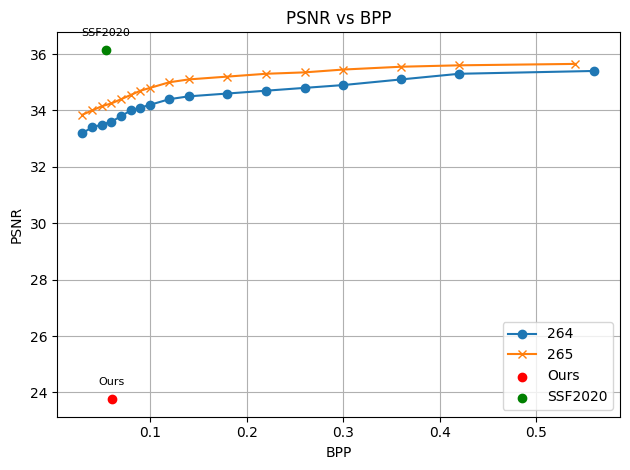

In [1]:
import matplotlib.pyplot as plt

# Your PSNR vs BPP data for 264 and 265 (already plotted)
bpp_264 = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.18, 0.22, 0.26, 0.3, 0.36, 0.42, 0.56]
psnr_264 = [33.2, 33.4, 33.5, 33.6, 33.8, 34.0, 34.1, 34.2, 34.4, 34.5, 34.6, 34.7, 34.8, 34.9, 35.1, 35.3, 35.4]

bpp_265 = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.18, 0.22, 0.26, 0.3, 0.36, 0.42, 0.54]
psnr_265 = [33.85, 34.0, 34.15, 34.25, 34.4, 34.55, 34.7, 34.8, 35.0, 35.1, 35.2, 35.3, 35.35, 35.45, 35.55, 35.6, 35.65]

# Add your new data points
bpp_ours = 0.0604
psnr_ours = 23.76

bpp_ssf = 0.054
psnr_ssf = 36.15

# Plot existing data
plt.plot(bpp_264, psnr_264, label="264", marker='o')
plt.plot(bpp_265, psnr_265, label="265", marker='x')

# Add your points
plt.scatter(bpp_ours, psnr_ours, color='red', label='Ours', zorder=5)
plt.scatter(bpp_ssf, psnr_ssf, color='green', label='SSF2020', zorder=5)

# Annotate points
plt.annotate("Ours", (bpp_ours, psnr_ours), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
plt.annotate("SSF2020", (bpp_ssf, psnr_ssf), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel("BPP")
plt.ylabel("PSNR")
plt.title("PSNR vs BPP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


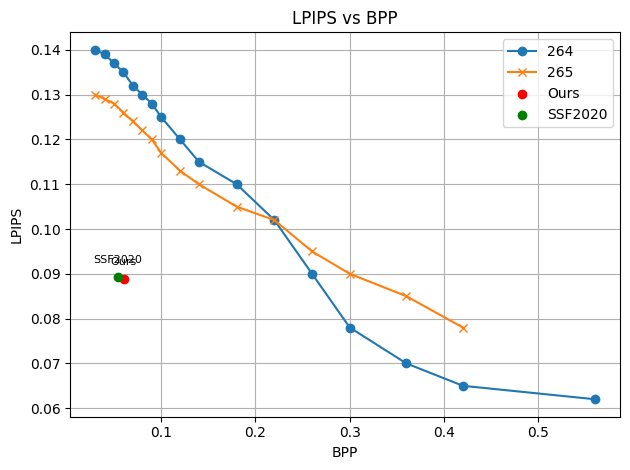

In [2]:

bpp_264 = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.18, 0.22, 0.26, 0.3, 0.36, 0.42, 0.56]
lpips_264 = [0.14, 0.139, 0.137, 0.135, 0.132, 0.13, 0.128, 0.125, 0.12, 0.115, 0.11, 0.102, 0.09, 0.078, 0.07, 0.065, 0.062]

bpp_265 = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.18, 0.22, 0.26, 0.3, 0.36, 0.42]
lpips_265 = [0.13, 0.129, 0.128, 0.126, 0.124, 0.122, 0.12, 0.117, 0.113, 0.11, 0.105, 0.102, 0.095, 0.09, 0.085, 0.078]

# New points
bpp_ours = 0.0604
lpips_ours = 0.08894

bpp_ssf = 0.054
lpips_ssf = 0.08926

# Plot
plt.plot(bpp_264, lpips_264, label="264", marker='o')
plt.plot(bpp_265, lpips_265, label="265", marker='x')

# Add scatter points
plt.scatter(bpp_ours, lpips_ours, color='red', label='Ours', zorder=5)
plt.scatter(bpp_ssf, lpips_ssf, color='green', label='SSF2020', zorder=5)

# Annotate
plt.annotate("Ours", (bpp_ours, lpips_ours), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
plt.annotate("SSF2020", (bpp_ssf, lpips_ssf), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel("BPP")
plt.ylabel("LPIPS")
plt.title("LPIPS vs BPP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


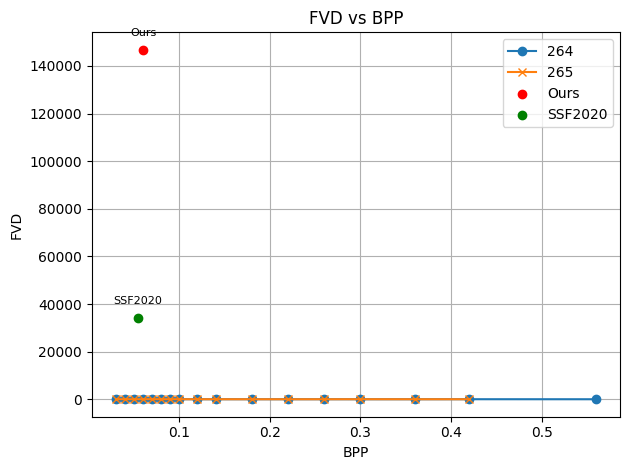

In [4]:
import matplotlib.pyplot as plt

# Sample FVD vs BPP data for H.264 and H.265
bpp_264 = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.18, 0.22, 0.26, 0.3, 0.36, 0.42, 0.56]
fvd_264 = [171, 92, 80, 83, 78, 66, 49, 65, 45, 46, 44, 44, 45, 40, 42, 53, 40]

bpp_265 = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.18, 0.22, 0.26, 0.3, 0.36, 0.42]
fvd_265 = [67, 57, 50, 58, 70, 63, 56, 58, 55, 53, 41, 39, 45, 55, 43, 44]

# New data points
bpp_ours = 0.0604
fvd_ours = 1.468e5

bpp_ssf = 0.054
fvd_ssf = 34191.83

# Plot
plt.plot(bpp_264, fvd_264, label="264", marker='o')
plt.plot(bpp_265, fvd_265, label="265", marker='x')

# Add scatter points for SSF and Ours
plt.scatter(bpp_ours, fvd_ours, color='red', label='Ours', zorder=5)
plt.scatter(bpp_ssf, fvd_ssf, color='green', label='SSF2020', zorder=5)

# Annotate
plt.annotate("Ours", (bpp_ours, fvd_ours), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)
plt.annotate("SSF2020", (bpp_ssf, fvd_ssf), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

plt.xlabel("BPP")
plt.ylabel("FVD")
plt.title("FVD vs BPP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


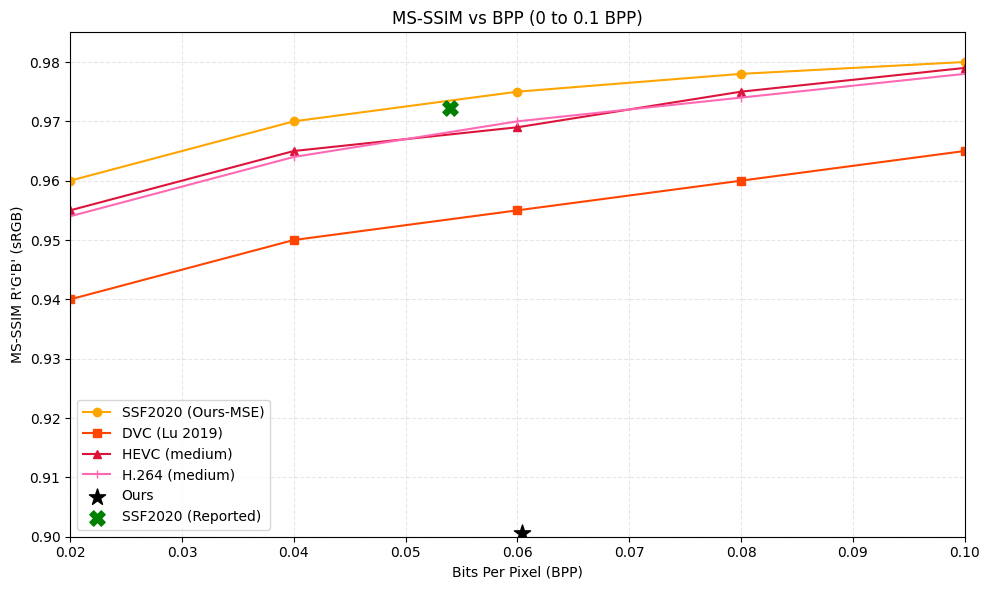

In [15]:
import matplotlib.pyplot as plt

# Existing curves (dummy example values for other methods)
bpp = [0.02, 0.04, 0.06, 0.08, 0.1]
ms_ssim_h264 = [0.954, 0.964, 0.970, 0.974, 0.978]
ms_ssim_hevc = [0.955, 0.965, 0.969, 0.975, 0.979]
ms_ssim_dvc = [0.940, 0.950, 0.955, 0.960, 0.965]
ms_ssim_ssf = [0.960, 0.970, 0.975, 0.978, 0.980]

# New points
bpp_ours = 0.0604
ms_ssim_ours = 0.9006

bpp_ssf = 0.054
ms_ssim_ssf_point = 0.9722

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(bpp, ms_ssim_ssf, label='SSF2020 (Ours-MSE)', color='orange', marker='o')
plt.plot(bpp, ms_ssim_dvc, label='DVC (Lu 2019)', color='orangered', marker='s')
plt.plot(bpp, ms_ssim_hevc, label='HEVC (medium)', color='crimson', marker='^')
plt.plot(bpp, ms_ssim_h264, label='H.264 (medium)', color='hotpink', marker='|')

# Add custom points
plt.scatter(bpp_ours, ms_ssim_ours, color='black', marker='*', s=150, label='Ours', zorder=5)
plt.scatter(bpp_ssf, ms_ssim_ssf_point, color='green', marker='X', s=120, label='SSF2020 (Reported)', zorder=6)

plt.xlabel("Bits Per Pixel (BPP)")
plt.ylabel("MS-SSIM R'G'B' (sRGB)")
plt.title("MS-SSIM vs BPP (0 to 0.1 BPP)")
plt.xlim(0.02, 0.1)
plt.ylim(0.90, 0.985)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("ms_ssim_bpp_custom_points.png", dpi=300)
plt.show()
